In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    brier_score_loss, roc_curve, precision_recall_curve, confusion_matrix
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap
import joblib
import json
import os

print("All imports successful")

All imports successful


In [2]:
df = pd.read_csv("C:\\Users\\geethesh.ganipudi\\banking_churn\\dataset\\finance_marketing_01.csv")
print(f'Dataset shape: {df.shape}')
print(f'Churn rate:      {df["churned"].mean():.3f}  ({df["churned"].sum():,} churned)')
print(f'Cross-sell rate: {df["cross_sell_accepted"].mean():.3f}  ({df["cross_sell_accepted"].sum():,} accepted)')
df.head(3)

Dataset shape: (60000, 44)
Churn rate:      0.163  (9,762 churned)
Cross-sell rate: 0.245  (14,702 accepted)


,customer_id,age,gender,marital_status,education_level,occupation,city_tier,region,annual_income,account_type,...,click_through_rate,preferred_campaign_channel,last_campaign_type,days_since_last_campaign,campaign_offer_category,clv_score,clv_segment,risk_segment,churned,cross_sell_accepted
0,CUST000001,56,Male,Married,Master,Student,Tier 3,North,18269,Basic,...,0.1,Push Notification,Retention,43,No Active Offer,290,Low,Very High Risk,0,0
1,CUST000002,69,Female,Married,Bachelor,Salaried,Tier 3,East,92215,Premium,...,0.0,SMS,Upgrade,268,Savings Plan,359,Medium,High Risk,0,0
2,CUST000003,46,Male,Married,High School,Retired,Tier 3,Central,25823,Basic,...,0.1,SMS,Cross-sell,341,No Active Offer,381,Medium,High Risk,1,0


In [3]:
info = pd.DataFrame({
    'dtype':    df.dtypes,
    'missing':  df.isnull().sum(),
    'missing%': (df.isnull().mean() * 100).round(2)
})
print("Columns with missing values")
print(info[info['missing'] > 0].to_string())

Columns with missing values
             dtype  missing  missing%
nps_score  float64     6057      10.1


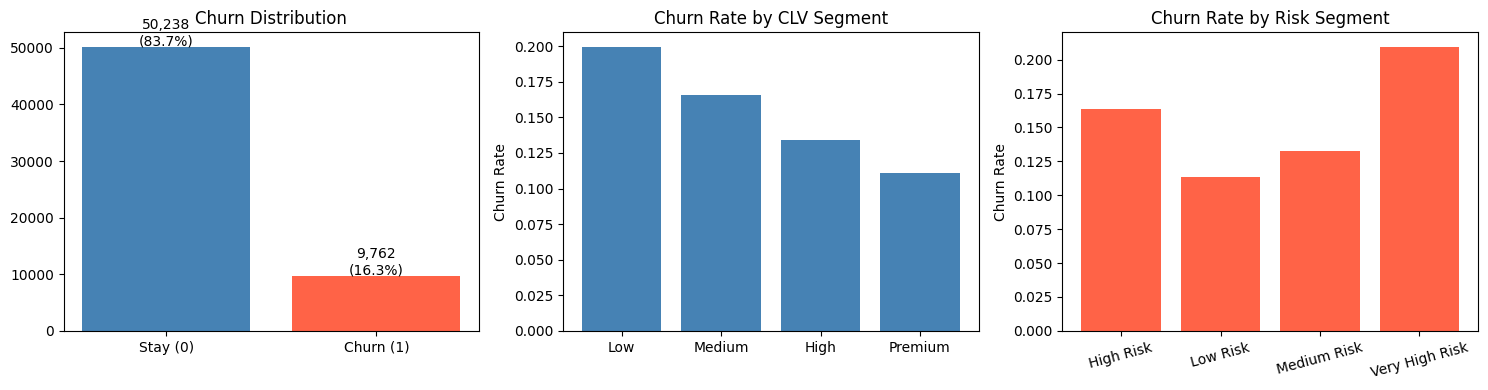

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

churn_counts = df['churned'].value_counts()
axes[0].bar(['Stay (0)', 'Churn (1)'], churn_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Churn Distribution')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')

clv_churn = df.groupby('clv_segment')['churned'].mean().reindex(['Low','Medium','High','Premium'])
axes[1].bar(clv_churn.index, clv_churn.values, color='steelblue')
axes[1].set_title('Churn Rate by CLV Segment')
axes[1].set_ylabel('Churn Rate')

risk_churn = df.groupby('risk_segment')['churned'].mean()
axes[2].bar(risk_churn.index, risk_churn.values, color='tomato')
axes[2].set_title('Churn Rate by Risk Segment')
axes[2].set_ylabel('Churn Rate')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

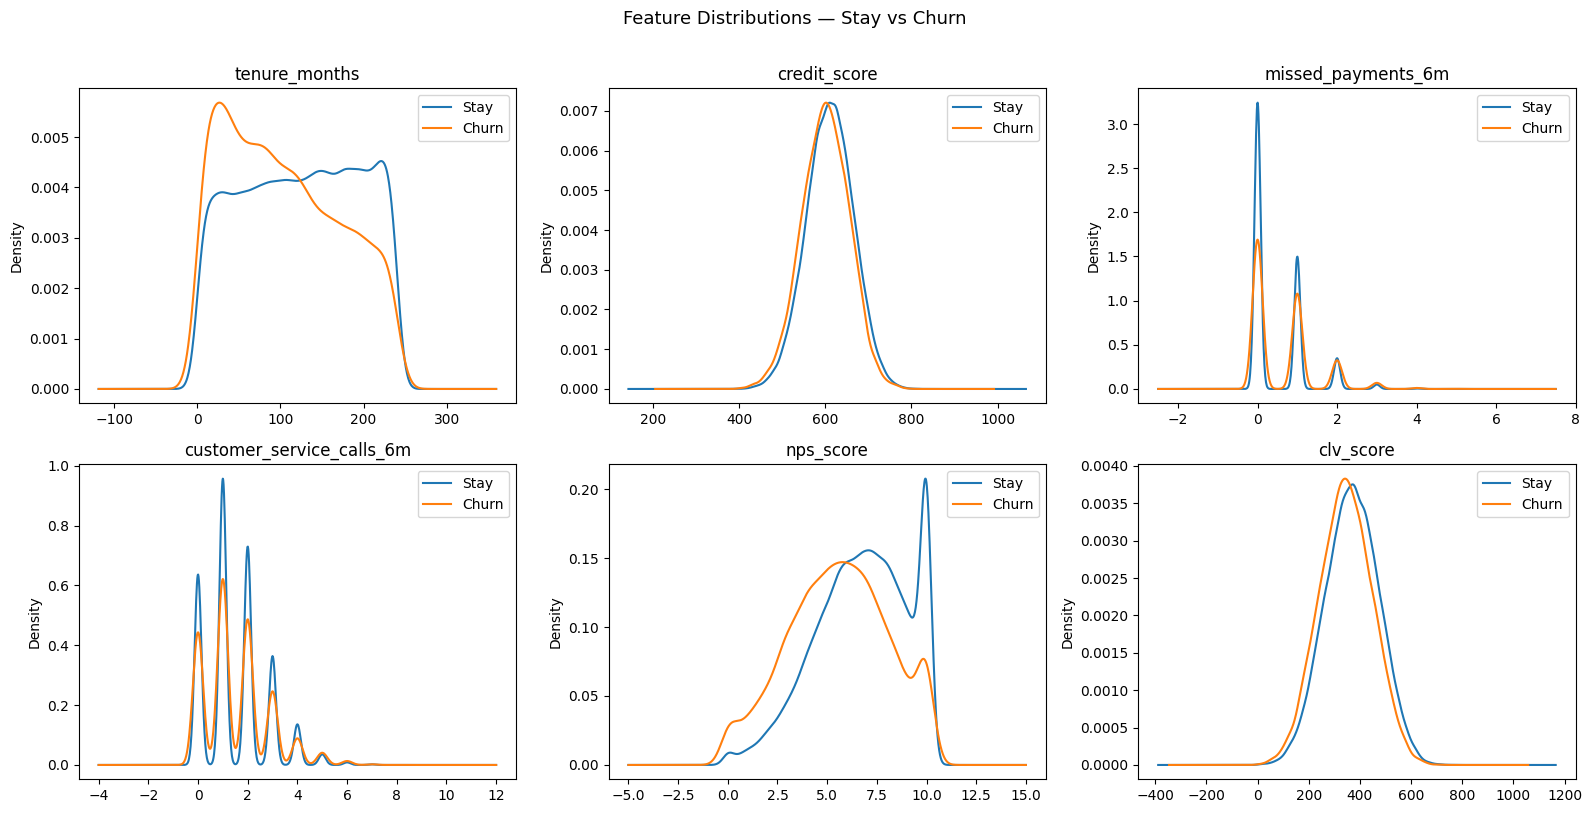

In [5]:
features_to_plot = [
    'tenure_months', 'credit_score', 'missed_payments_6m',
    'customer_service_calls_6m', 'nps_score', 'clv_score'
]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), features_to_plot):
    df.groupby('churned')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(col)
    ax.legend(['Stay', 'Churn'])
plt.suptitle('Feature Distributions — Stay vs Churn', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

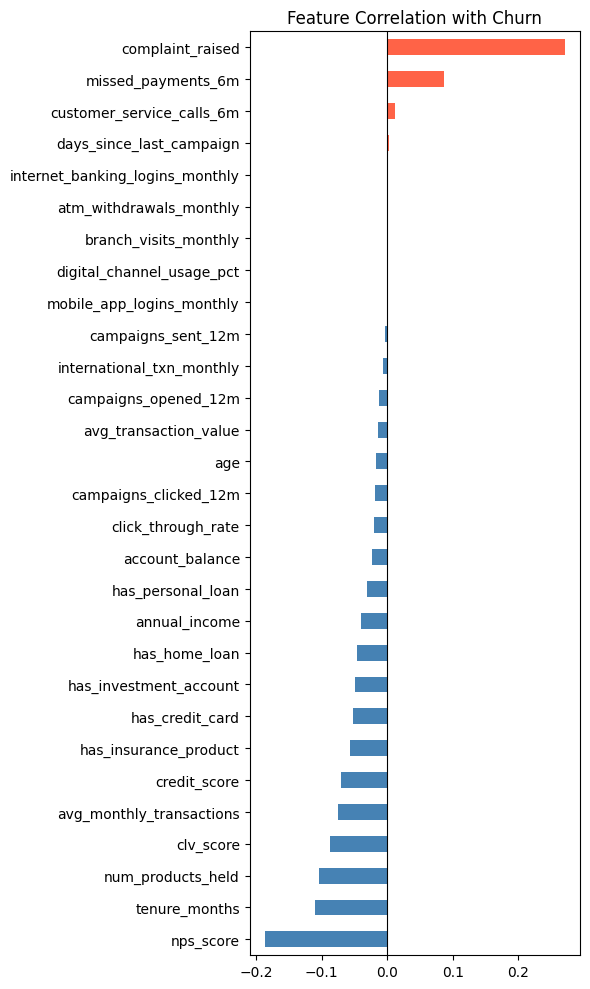

In [6]:
numeric_df = df.select_dtypes('number').drop(columns=['cross_sell_accepted'])
corr_with_churn = numeric_df.corr()['churned'].drop('churned').sort_values()
fig, ax = plt.subplots(figsize=(6, 10))
corr_with_churn.plot(kind='barh', ax=ax, color=['tomato' if v > 0 else 'steelblue' for v in corr_with_churn])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Churn')
plt.tight_layout()
plt.show()

In [7]:
DROP_COLS = [
    'customer_id',
    'clv_segment',      
    'risk_segment',       
    'internet_banking_logins_monthly',   
    'mobile_app_logins_monthly',         
]

df_model = df.drop(columns=DROP_COLS + ['cross_sell_accepted']).copy()
print(f'Model dataframe shape: {df_model.shape}')
print(f'Remaining columns ({len(df_model.columns)}):')
print(df_model.columns.tolist())

Model dataframe shape: (60000, 38)
Remaining columns (38):
['age', 'gender', 'marital_status', 'education_level', 'occupation', 'city_tier', 'region', 'annual_income', 'account_type', 'tenure_months', 'credit_score', 'account_balance', 'num_products_held', 'has_credit_card', 'has_personal_loan', 'has_home_loan', 'has_investment_account', 'has_insurance_product', 'avg_monthly_transactions', 'avg_transaction_value', 'digital_channel_usage_pct', 'atm_withdrawals_monthly', 'international_txn_monthly', 'missed_payments_6m', 'branch_visits_monthly', 'customer_service_calls_6m', 'complaint_raised', 'nps_score', 'campaigns_sent_12m', 'campaigns_opened_12m', 'campaigns_clicked_12m', 'click_through_rate', 'preferred_campaign_channel', 'last_campaign_type', 'days_since_last_campaign', 'campaign_offer_category', 'clv_score', 'churned']


In [8]:
def engineer_features(df_in):
    df_out = df_in.copy()

    df_out['campaign_open_rate'] = df_out['campaigns_opened_12m'] / (df_out['campaigns_sent_12m'] + 1)
    df_out['balance_income_ratio'] = df_out['account_balance'] / (df_out['annual_income'] + 1)
    df_out['savings_efficiency']   = df_out['account_balance'] / (df_out['avg_monthly_transactions'] + 1)
    df_out['risk_indicator']       = df_out['missed_payments_6m'] + df_out['complaint_raised']
    df_out['monthly_txn_volume']   = df_out['avg_monthly_transactions'] * df_out['avg_transaction_value']
    nps_median = df_out['nps_score'].median()
    nps_filled = df_out['nps_score'].fillna(nps_median)
    df_out['complaint_nps_interaction'] = (10 - nps_filled) * (df_out['complaint_raised'] + 1)
    df_out['products_per_tenure']  = df_out['num_products_held'] / (df_out['tenure_months'] / 12 + 1)

    return df_out

df_model = engineer_features(df_model)
print(f'Shape after feature engineering: {df_model.shape}')

Shape after feature engineering: (60000, 45)


In [9]:
ordinal_cols_map = {
    'education_level': ['High School', 'Bachelor', 'Master', 'PhD'],
    'city_tier':       ['Tier 3', 'Tier 2', 'Tier 1'],
}

nominal_cols = [
    'gender', 'marital_status', 'occupation', 'region',
    'account_type', 'preferred_campaign_channel',
    'last_campaign_type', 'campaign_offer_category'
]

numeric_cols = (
    df_model.drop(columns=['churned'])
    .select_dtypes('number')
    .columns.tolist()
)

print(f'Numeric features:  {len(numeric_cols)}')
print(f'Ordinal features:  {len(ordinal_cols_map)}')
print(f'Nominal features:  {len(nominal_cols)}')
print(f'Total input features: {len(numeric_cols) + len(ordinal_cols_map) + len(nominal_cols)}')

Numeric features:  34
Ordinal features:  2
Nominal features:  8
Total input features: 44


In [10]:
numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')), 
    ('scale',  StandardScaler())
])

ordinal_pipeline = Pipeline([
    ('encode', OrdinalEncoder(
        categories=[ordinal_cols_map[c] for c in ordinal_cols_map],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

nominal_pipeline = Pipeline([
    ('encode', OneHotEncoder(
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    ))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,              numeric_cols),
    ('ord', ordinal_pipeline,              list(ordinal_cols_map.keys())),
    ('nom', nominal_pipeline,              nominal_cols),
], remainder='drop')

print('Preprocessor built successfully.')

Preprocessor built successfully.


In [11]:
X = df_model.drop(columns=['churned'])
y = df_model['churned']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f'Train:     {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]:,} rows ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test:      {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nTrain churn rate:     {y_train.mean():.3f}')
print(f'Validation churn rate: {y_val.mean():.3f}')
print(f'Test churn rate:      {y_test.mean():.3f}')

Train:     42,000 rows (70.0%)
Validation: 9,000 rows (15.0%)
Test:      9,000 rows (15.0%)

Train churn rate:     0.163
Validation churn rate: 0.163
Test churn rate:      0.163


In [12]:
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print(f'Preprocessed train shape: {X_train_prep.shape}')
print(f'Preprocessed validation shape: {X_val_prep.shape}')
print(f'Preprocessed test shape:  {X_test_prep.shape}')

print(f'\nOriginal class distribution in training:')
print(f'  Stay:  {(y_train == 0).sum():,}')
print(f'  Churn: {(y_train == 1).sum():,}')

Preprocessed train shape: (42000, 64)
Preprocessed validation shape: (9000, 64)
Preprocessed test shape:  (9000, 64)

Original class distribution in training:
  Stay:  35,167
  Churn: 6,833


In [13]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    auc    = roc_auc_score(y_te, y_prob)
    pr_auc = average_precision_score(y_te, y_prob)
    brier  = brier_score_loss(y_te, y_prob)

    print("\n")
    print(f"  {name} : ")
    print(classification_report(y_te, y_pred, target_names=['Stay', 'Churn']))
    print(f"  AUC-ROC : {auc:.4f}")
    print(f"  PR-AUC  : {pr_auc:.4f}")
    print(f"  Brier   : {brier:.4f}\n")
    return {'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
            'auc': auc, 'pr_auc': pr_auc, 'brier': brier}

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

baseline_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=0.1, random_state=42,
        class_weight='balanced'  
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=10,
        min_samples_leaf=20, n_jobs=-1, random_state=42,
        class_weight='balanced' 
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',
        random_state=42, n_jobs=-1,
        scale_pos_weight=scale_pos 
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        num_leaves=63, random_state=42, n_jobs=-1, verbose=-1,
        class_weight='balanced'  
    ),
}

results = {}
for name, model in baseline_models.items():
    results[name] = evaluate_model(
        name, model,
        X_train_prep, y_train,
        X_test_prep, y_test
    )

best_name = max(results, key=lambda n: results[n]['pr_auc'])
print(f"\n")
print(f" Best baseline model by PR-AUC: {best_name}  ({results[best_name]['pr_auc']:.4f})")



  Logistic Regression : 
              precision    recall  f1-score   support

        Stay       0.90      0.72      0.80      7536
       Churn       0.29      0.60      0.39      1464

    accuracy                           0.70      9000
   macro avg       0.60      0.66      0.60      9000
weighted avg       0.80      0.70      0.74      9000

  AUC-ROC : 0.7220
  PR-AUC  : 0.3703
  Brier   : 0.2077



  Random Forest : 
              precision    recall  f1-score   support

        Stay       0.89      0.81      0.85      7536
       Churn       0.34      0.50      0.40      1464

    accuracy                           0.76      9000
   macro avg       0.61      0.65      0.62      9000
weighted avg       0.80      0.76      0.78      9000

  AUC-ROC : 0.7161
  PR-AUC  : 0.3621
  Brier   : 0.1908



  XGBoost : 
              precision    recall  f1-score   support

        Stay       0.90      0.76      0.82      7536
       Churn       0.30      0.55      0.39      1464

   

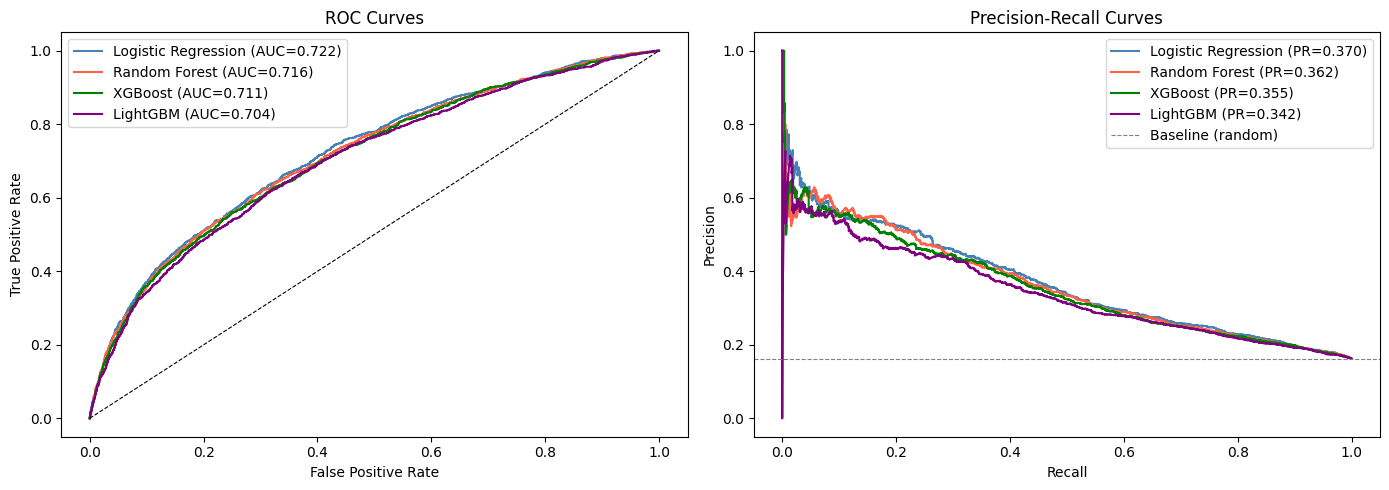

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'tomato', 'green', 'purple']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])

    ax1.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=color)
    ax2.plot(rec, prec, label=f"{name} (PR={res['pr_auc']:.3f})", color=color)

ax1.plot([0,1],[0,1],'k--', linewidth=0.8)
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves'); ax1.legend()

ax2.axhline(y_test.mean(), color='grey', linestyle='--', linewidth=0.8, label='Baseline (random)')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves'); ax2.legend()

plt.tight_layout()
plt.show()

In [15]:
from sklearn.calibration import CalibratedClassifierCV

lr_param_grid = {
    'C':        [0.001, 0.01, 0.1, 1, 10],
    'penalty':  ['l1', 'l2'],
    'solver':   ['liblinear'],    
    'max_iter': [1000]
}

lr_base = LogisticRegression(class_weight='balanced', random_state=42)

lr_search = RandomizedSearchCV(
    lr_base, lr_param_grid,
    n_iter=20,
    scoring='average_precision', 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42, n_jobs=-1, refit=True
)

lr_search.fit(X_train_prep, y_train)  

print('Best parameters:')
for k, v in lr_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV PR-AUC: {lr_search.best_score_:.4f}')

Best parameters:
  solver: liblinear
  penalty: l1
  max_iter: 1000
  C: 0.01

Best CV PR-AUC: 0.3827


In [16]:
calibrated_lr = CalibratedClassifierCV(
    lr_search.best_estimator_, method='sigmoid', cv=5
)
calibrated_lr.fit(X_train_prep, y_train)

final_model = calibrated_lr

y_pred_final = final_model.predict(X_test_prep)
y_prob_final = final_model.predict_proba(X_test_prep)[:, 1]

print("  TUNED + CALIBRATED Logistic Regression — Final Test")
print(classification_report(y_test, y_pred_final, target_names=['Stay', 'Churn']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob_final):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_prob_final):.4f}")
print(f"Brier   : {brier_score_loss(y_test, y_prob_final):.4f}")

print(f"\nCalibration check:")
print(f"  True churn base rate   : {y_test.mean():.4f}")
print(f"  Mean predicted prob    : {y_prob_final.mean():.4f}")
print(f"  Gap  : {abs(y_prob_final.mean() - y_test.mean()):.4f}")

results['LR (Tuned + Calibrated)'] = {
    'model': final_model, 'y_pred': y_pred_final, 'y_prob': y_prob_final,
    'auc':    roc_auc_score(y_test, y_prob_final),
    'pr_auc': average_precision_score(y_test, y_prob_final),
    'brier':  brier_score_loss(y_test, y_prob_final)
}

  TUNED + CALIBRATED Logistic Regression — Final Test
              precision    recall  f1-score   support

        Stay       0.85      0.98      0.91      7536
       Churn       0.57      0.14      0.22      1464

    accuracy                           0.84      9000
   macro avg       0.71      0.56      0.57      9000
weighted avg       0.81      0.84      0.80      9000

AUC-ROC : 0.7232
PR-AUC  : 0.3761
Brier   : 0.1208

Calibration check:
  True churn base rate   : 0.1627
  Mean predicted prob    : 0.1638
  Gap  : 0.0011


In [17]:
inner_lr = lr_search.best_estimator_

ohe_feature_names = (
    preprocessor.named_transformers_['nom']['encode']
    .get_feature_names_out(nominal_cols)
    .tolist()
)
all_feature_names = numeric_cols + list(ordinal_cols_map.keys()) + ohe_feature_names

X_val_df = pd.DataFrame(X_val_prep, columns=all_feature_names)

print(f'Feature matrix shape: {X_val_df.shape}')
print(f'Feature names count:  {len(all_feature_names)}')

masker = shap.maskers.Independent(X_val_df, max_samples=len(X_val_df))
explainer = shap.LinearExplainer(inner_lr, masker)
shap_values = explainer.shap_values(X_val_df)

print('SHAP values computed.')

Feature matrix shape: (9000, 64)
Feature names count:  64
SHAP values computed.


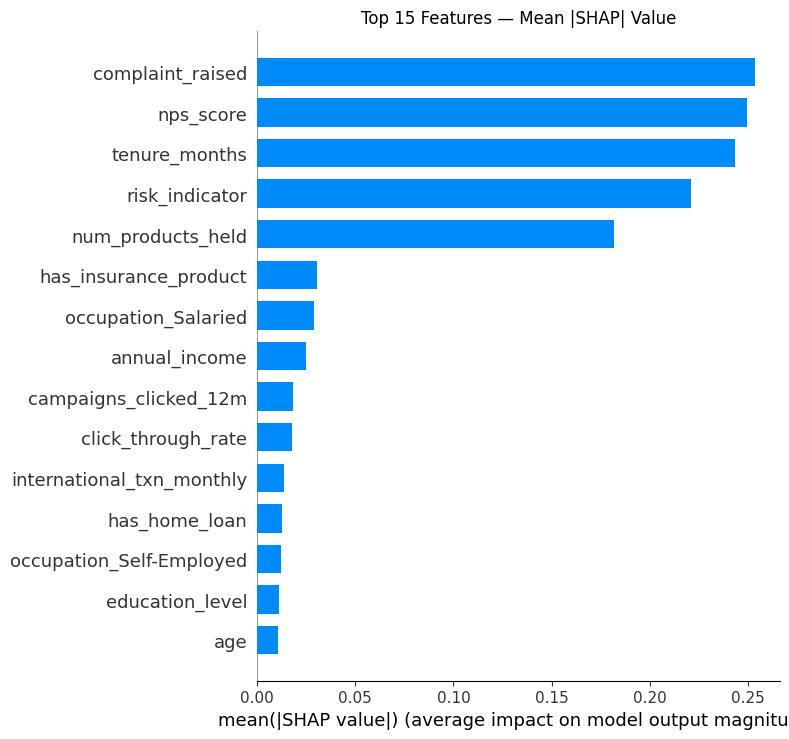

In [18]:
shap.summary_plot(shap_values, X_val_df, plot_type='bar', max_display=15, show=False)
plt.title('Top 15 Features — Mean |SHAP| Value')
plt.tight_layout()
plt.show()

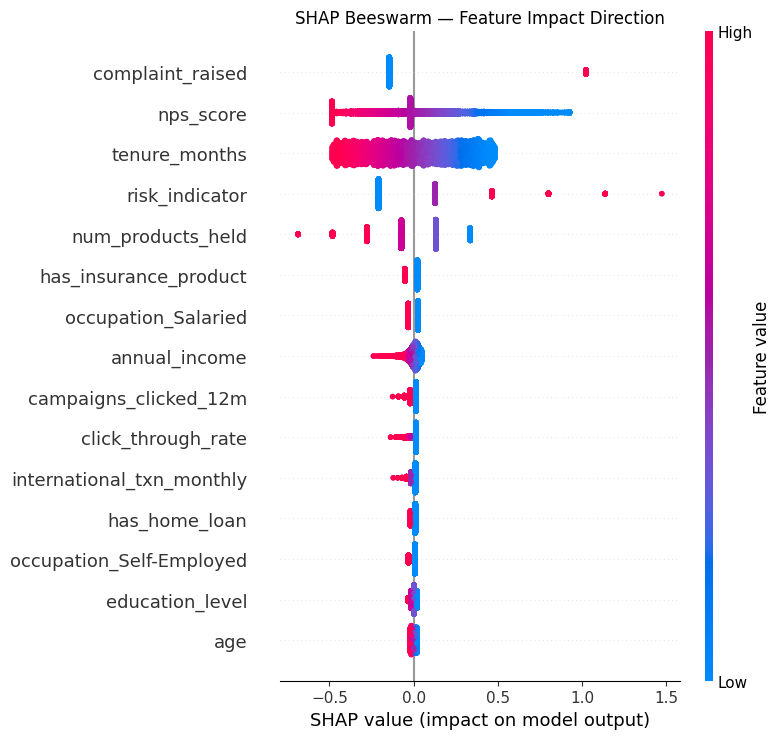

In [19]:
shap.summary_plot(shap_values, X_val_df, max_display=15, show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction')
plt.tight_layout()
plt.show()

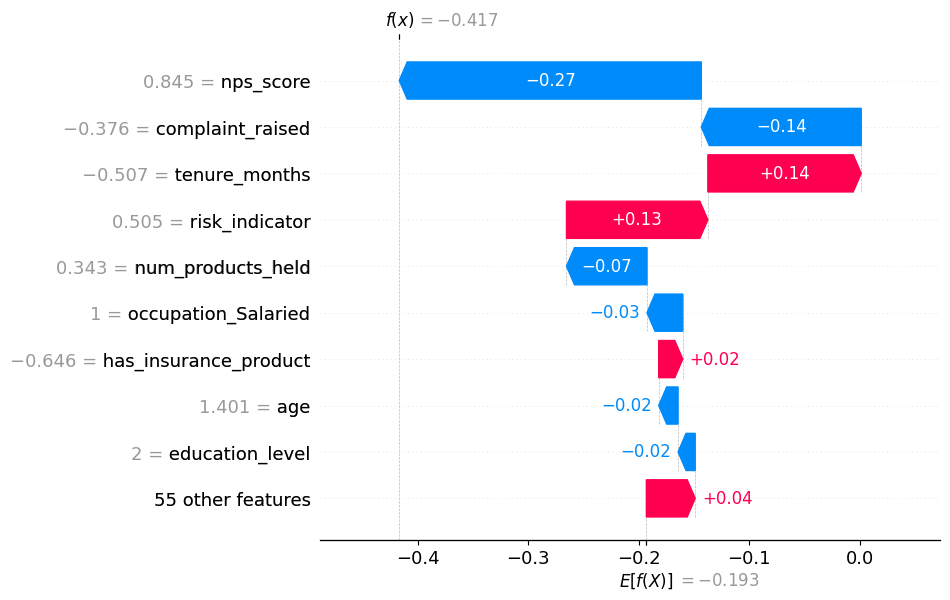

In [20]:
customer_idx = 0   
shap.waterfall_plot(shap.Explanation(
    values        = shap_values[customer_idx],
    base_values   = explainer.expected_value,
    data          = X_val_df.iloc[customer_idx],
    feature_names = all_feature_names
))

Validation set size:        9,000
Max contacts allowed: 2,250  (25% capacity cap)
True churners in validation: 1,465
  UNCONSTRAINED (naive):
    Threshold : 0.0316
    Contacts  : 8,949  (99.4% of customers) ← impractical
    Profit    : $352,214

  CAPACITY-CONSTRAINED (realistic, ≤2,250 contacts):
    Threshold : 0.1907
    Contacts  : 2,219  (24.7% of customers)
    Profit    : $183,859


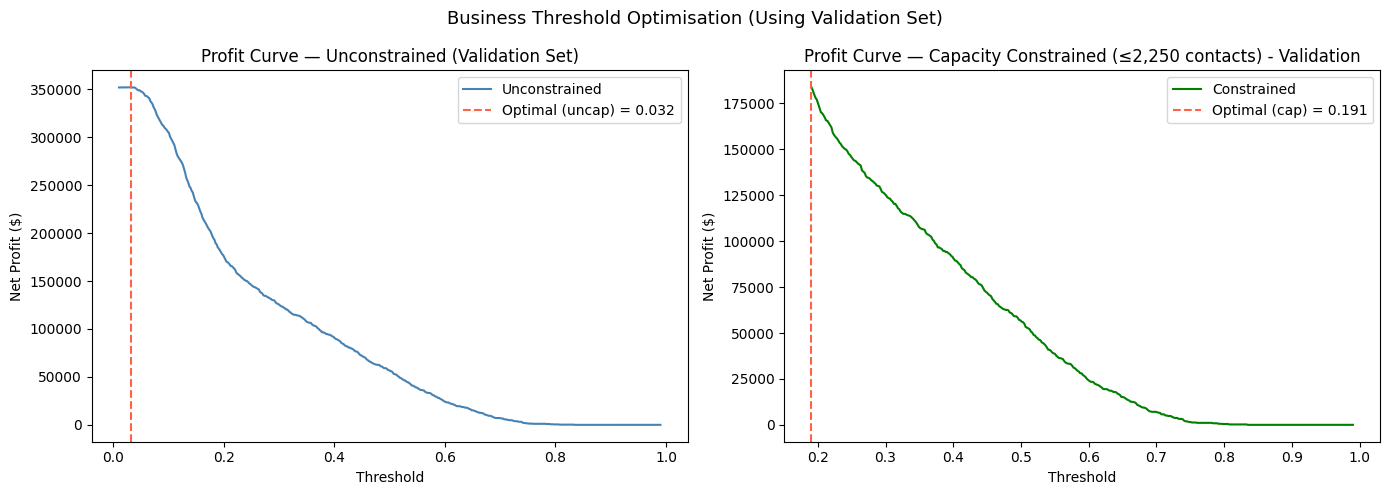

In [ ]:
COST_CONTACT   = 5
BASE_VALUE_SAVED = 100
CLV_MULTIPLIER = 0.5 

customer_value_saved = BASE_VALUE_SAVED + (X_val['clv_score'].values * CLV_MULTIPLIER)

n_active      = len(y_val)
MAX_CONTACTS  = int(0.25 * len(y_val))  

print(f"Validation set size:        {len(y_val):,}")
print(f"Max contacts allowed: {MAX_CONTACTS:,}  (25% capacity cap)")
print(f"True churners in validation: {(y_val==1).sum():,}")

y_prob_val = final_model.predict_proba(X_val_prep)[:, 1]

thresholds    = np.linspace(0.01, 0.99, 500)
profits_uncap = []
profits_cap   = []

for t in thresholds:
    y_flag   = (y_prob_val >= t).astype(int)
    tp_mask  = (y_flag == 1) & (y_val == 1)
    contacts = y_flag.sum()
    total_value_saved = customer_value_saved[tp_mask].sum()
    profit_uncap = total_value_saved - (contacts * COST_CONTACT)
    profits_uncap.append(profit_uncap)

    if contacts <= MAX_CONTACTS:
        profits_cap.append(profit_uncap)
    else:
        profits_cap.append(np.nan)  

profits_uncap = np.array(profits_uncap, dtype=float)
profits_cap   = np.array(profits_cap,   dtype=float)

best_idx_uncap    = np.argmax(profits_uncap)
best_thresh_uncap = thresholds[best_idx_uncap]
best_profit_uncap = profits_uncap[best_idx_uncap]

valid_mask        = ~np.isnan(profits_cap)
best_idx_cap      = np.nanargmax(profits_cap)
best_thresh_cap   = thresholds[best_idx_cap]
best_profit_cap   = profits_cap[best_idx_cap]

contacts_at_uncap = (y_prob_val >= best_thresh_uncap).sum()
contacts_at_cap   = (y_prob_val >= best_thresh_cap).sum()

print(f"  UNCONSTRAINED (naive):")
print(f"    Threshold : {best_thresh_uncap:.4f}")
print(f"    Contacts  : {contacts_at_uncap:,}  ({contacts_at_uncap/len(y_val)*100:.1f}% of customers) ← impractical")
print(f"    Profit    : ${best_profit_uncap:,.0f}")

print(f"\n  CAPACITY-CONSTRAINED (realistic, ≤{MAX_CONTACTS:,} contacts):")
print(f"    Threshold : {best_thresh_cap:.4f}")
print(f"    Contacts  : {contacts_at_cap:,}  ({contacts_at_cap/len(y_val)*100:.1f}% of customers)")
print(f"    Profit    : ${best_profit_cap:,.0f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(thresholds, profits_uncap, color='steelblue', label='Unconstrained')
ax1.axvline(best_thresh_uncap, color='tomato', linestyle='--',
            label=f'Optimal (uncap) = {best_thresh_uncap:.3f}')
ax1.set_xlabel('Threshold'); ax1.set_ylabel('Net Profit ($)')
ax1.set_title('Profit Curve — Unconstrained (Validation Set)')
ax1.legend()

ax2.plot(thresholds[valid_mask], profits_cap[valid_mask], color='green', label='Constrained')
ax2.axvline(best_thresh_cap, color='tomato', linestyle='--',
            label=f'Optimal (cap) = {best_thresh_cap:.3f}')
ax2.set_xlabel('Threshold'); ax2.set_ylabel('Net Profit ($)')
ax2.set_title(f'Profit Curve — Capacity Constrained (≤{MAX_CONTACTS:,} contacts) - Validation')
ax2.legend()

plt.suptitle('Business Threshold Optimisation (Using Validation Set)', fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
print(" Thresholds by recall target (capacity-constrained, using validation set):")
for target_recall in [0.40, 0.50, 0.60, 0.70, 0.80]:
    for t in np.linspace(0.99, 0.01, 1000):
        y_flag   = (y_prob_val >= t).astype(int)
        contacts = y_flag.sum()
        if contacts > MAX_CONTACTS:
            continue   
        tp_mask = (y_flag == 1) & (y_val == 1)
        tp      = tp_mask.sum()
        recall  = tp / (y_val == 1).sum()
        if recall >= target_recall:
            profit = customer_value_saved[tp_mask].sum() - contacts * COST_CONTACT
            prec   = tp / contacts if contacts > 0 else 0
            print(f"  {target_recall*100:.0f}% recall  threshold={t:.4f} → "
                  f"contacts={contacts:,}  precision={prec:.2f}  profit=${profit:,.0f}")
            break
    else:
        print(f"  {target_recall*100:.0f}% recall → not achievable within capacity cap")

selected_threshold = best_thresh_cap
y_pred_business    = (y_prob_final >= selected_threshold).astype(int)

tp_mask_final  = (y_pred_business == 1) & (y_test == 1)
tp_final       = tp_mask_final.sum()
contacts_final = y_pred_business.sum()
prec_final     = tp_final / contacts_final if contacts_final > 0 else 0
rec_final      = tp_final / (y_test == 1).sum()
total_value_saved_final = (BASE_VALUE_SAVED + (X_test['clv_score'].values * CLV_MULTIPLIER))[tp_mask_final].sum()

print(f"\n Selected threshold (from validation set): {selected_threshold:.4f}")
print(f"   Contacts on TEST set:  {contacts_final:,}  ({contacts_final/len(y_test)*100:.1f}% of customers)")
print(f"   Precision on TEST set: {prec_final:.3f}  (1 in {1/prec_final:.1f} contacts is a real churner)")
print(f"   Recall on TEST set:    {rec_final:.3f}  ({tp_final:,} of {(y_test==1).sum():,} churners caught)")
print(f"   Profit on TEST set:    ${total_value_saved_final - contacts_final * COST_CONTACT:,.0f}")

print("\nClassification report at business threshold (TEST set):")
print(classification_report(y_test, y_pred_business, target_names=['Stay', 'Churn']))

 Thresholds by recall target (capacity-constrained, using validation set):
  40% recall  threshold=0.2454 → contacts=1,466  precision=0.40  profit=$148,220
  50% recall  threshold=0.1925 → contacts=2,188  precision=0.34  profit=$182,930
  60% recall → not achievable within capacity cap
  70% recall → not achievable within capacity cap
  80% recall → not achievable within capacity cap

 Selected threshold (from validation set): 0.1907
   Contacts on TEST set:  2,205  (24.5% of customers)
   Precision on TEST set: 0.336  (1 in 3.0 contacts is a real churner)
   Recall on TEST set:    0.506  (741 of 1,464 churners caught)
   Profit on TEST set:    $183,770

Classification report at business threshold (TEST set):
              precision    recall  f1-score   support

        Stay       0.89      0.81      0.85      7536
       Churn       0.34      0.51      0.40      1464

    accuracy                           0.76      9000
   macro avg       0.61      0.66      0.63      9000
weighted 

In [23]:


from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV

print("  XGBOOST CHURN MODEL TUNING")

xgb_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 1, 10],
    'reg_lambda': [0, 0.1, 1, 10]
}

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_search = RandomizedSearchCV(
    xgb_base, 
    xgb_param_grid,
    n_iter=50,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nFitting XGBoost randomized search")
xgb_search.fit(X_train_prep, y_train)

print("\n")
print("BEST PARAMETERS FOUND:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV PR-AUC: {xgb_search.best_score_:.4f}")

  XGBOOST CHURN MODEL TUNING

Fitting XGBoost randomized search
Fitting 5 folds for each of 50 candidates, totalling 250 fits


BEST PARAMETERS FOUND:
  subsample: 1.0
  reg_lambda: 1
  reg_alpha: 10
  n_estimators: 100
  min_child_weight: 3
  max_depth: 3
  learning_rate: 0.05
  colsample_bytree: 1.0

Best CV PR-AUC: 0.3784


In [24]:


print("\nTUNED + Calibrating XGBoost model - Final Test")
xgb_calibrated = CalibratedClassifierCV(
    xgb_search.best_estimator_,
    method='sigmoid',
    cv=5
)
xgb_calibrated.fit(X_train_prep, y_train)

y_pred_xgb = xgb_calibrated.predict(X_test_prep)
y_prob_xgb = xgb_calibrated.predict_proba(X_test_prep)[:, 1]

print(classification_report(y_test, y_pred_xgb, target_names=['Stay', 'Churn']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_prob_xgb):.4f}")
print(f"Brier   : {brier_score_loss(y_test, y_prob_xgb):.4f}")

print(f"\nCalibration check:")
print(f"  True churn base rate   : {y_test.mean():.4f}")
print(f"  Mean predicted prob    : {y_prob_xgb.mean():.4f}")
print(f"  Gap                    : {abs(y_prob_xgb.mean() - y_test.mean()):.4f}")

xgb_results = {
    'model': xgb_calibrated,
    'y_pred': y_pred_xgb,
    'y_prob': y_prob_xgb,
    'auc': roc_auc_score(y_test, y_prob_xgb),
    'pr_auc': average_precision_score(y_test, y_prob_xgb),
    'brier': brier_score_loss(y_test, y_prob_xgb)
}


TUNED + Calibrating XGBoost model - Final Test
              precision    recall  f1-score   support

        Stay       0.85      0.98      0.91      7536
       Churn       0.56      0.12      0.19      1464

    accuracy                           0.84      9000
   macro avg       0.71      0.55      0.55      9000
weighted avg       0.80      0.84      0.80      9000

AUC-ROC : 0.7210
PR-AUC  : 0.3716
Brier   : 0.1214

Calibration check:
  True churn base rate   : 0.1627
  Mean predicted prob    : 0.1638
  Gap                    : 0.0011


In [25]:

print("  XGBOOST CHURN - BUSINESS THRESHOLD OPTIMIZATION")

y_prob_xgb_val = xgb_calibrated.predict_proba(X_val_prep)[:, 1]

customer_value_saved_val = BASE_VALUE_SAVED + (X_val['clv_score'].values * CLV_MULTIPLIER)

MAX_CONTACTS = int(0.25 * len(y_val))

print(f"Validation set size:        {len(y_val):,}")
print(f"Max contacts allowed: {MAX_CONTACTS:,}  (25% capacity cap)")
print(f"True churners in validation: {(y_val==1).sum():,}")

thresholds = np.linspace(0.01, 0.99, 500)
profits_xgb = []

for t in thresholds:
    y_flag = (y_prob_xgb_val >= t).astype(int)
    contacts = y_flag.sum()
    
    if contacts <= MAX_CONTACTS:
        tp_mask = (y_flag == 1) & (y_val == 1)
        total_value_saved = customer_value_saved_val[tp_mask].sum()
        profit = total_value_saved - (contacts * COST_CONTACT)
        profits_xgb.append(profit)
    else:
        profits_xgb.append(np.nan)

profits_xgb = np.array(profits_xgb, dtype=float)
valid_mask = ~np.isnan(profits_xgb)
best_idx_xgb = np.nanargmax(profits_xgb)
best_thresh_xgb = thresholds[best_idx_xgb]
best_profit_xgb = profits_xgb[best_idx_xgb]

contacts_at_opt = (y_prob_xgb_val >= best_thresh_xgb).sum()
tp_at_opt = ((y_prob_xgb_val >= best_thresh_xgb) & (y_val == 1)).sum()
precision_opt = tp_at_opt / contacts_at_opt if contacts_at_opt > 0 else 0
recall_opt = tp_at_opt / (y_val == 1).sum()


y_pred_xgb_biz = (y_prob_xgb >= best_thresh_xgb).astype(int)

tp_xgb_test = ((y_pred_xgb_biz == 1) & (y_test == 1)).sum()
contacts_xgb_test = y_pred_xgb_biz.sum()
prec_xgb_test = tp_xgb_test / contacts_xgb_test if contacts_xgb_test > 0 else 0
rec_xgb_test = tp_xgb_test / (y_test == 1).sum()
customer_value_saved_test = BASE_VALUE_SAVED + (X_test['clv_score'].values * CLV_MULTIPLIER)
profit_xgb_test = customer_value_saved_test[(y_pred_xgb_biz == 1) & (y_test == 1)].sum() - contacts_xgb_test * COST_CONTACT

print(f"\nXGBOOST PERFORMANCE ON TEST SET with optimal threshold:")
print(f"  Selected threshold (from validation set): {best_thresh_xgb:.4f}")
print(f"  Contacts:  {contacts_xgb_test:,} ({contacts_xgb_test/len(y_test)*100:.1f}% of test customers)")
print(f"  Precision: {prec_xgb_test:.3f}")
print(f"  Recall:    {rec_xgb_test:.3f}")
print(f"  Profit:    ${profit_xgb_test:,.0f}")

print("\nClassification report at business threshold (TEST set):")
print(classification_report(y_test, y_pred_xgb_biz, target_names=['Stay', 'Churn']))

  XGBOOST CHURN - BUSINESS THRESHOLD OPTIMIZATION
Validation set size:        9,000
Max contacts allowed: 2,250  (25% capacity cap)
True churners in validation: 1,465

XGBOOST PERFORMANCE ON TEST SET with optimal threshold:
  Selected threshold (from validation set): 0.1966
  Contacts:  2,259 (25.1% of test customers)
  Precision: 0.335
  Recall:    0.516
  Profit:    $187,101

Classification report at business threshold (TEST set):
              precision    recall  f1-score   support

        Stay       0.89      0.80      0.85      7536
       Churn       0.33      0.52      0.41      1464

    accuracy                           0.75      9000
   macro avg       0.61      0.66      0.63      9000
weighted avg       0.80      0.75      0.77      9000



In [26]:

print("  RANDOM FOREST HYPERPARAMETER TUNING")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV

rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'criterion': ['gini', 'entropy']
}

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_search = RandomizedSearchCV(
    rf_base,
    rf_param_grid,
    n_iter=50,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nFitting Random Forest randomized search...")
rf_search.fit(X_train_prep, y_train)

print("\n")
print("BEST RANDOM FOREST PARAMETERS FOUND:")
for k, v in rf_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV PR-AUC: {rf_search.best_score_:.4f}")

  RANDOM FOREST HYPERPARAMETER TUNING

Fitting Random Forest randomized search...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


BEST RANDOM FOREST PARAMETERS FOUND:
  n_estimators: 500
  min_samples_split: 10
  min_samples_leaf: 10
  max_features: sqrt
  max_depth: 10
  criterion: entropy
  class_weight: None

Best CV PR-AUC: 0.3744


In [27]:
print("  CALIBRATED RANDOM FOREST MODEL - FINAL TEST")

rf_calibrated = CalibratedClassifierCV(
    rf_search.best_estimator_,
    method='sigmoid',
    cv=5
)
rf_calibrated.fit(X_train_prep, y_train)

y_pred_rf = rf_calibrated.predict(X_test_prep)
y_prob_rf = rf_calibrated.predict_proba(X_test_prep)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=['Stay', 'Churn']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_prob_rf):.4f}")
print(f"Brier   : {brier_score_loss(y_test, y_prob_rf):.4f}")

print(f"\nCalibration check:")
print(f"  True churn base rate   : {y_test.mean():.4f}")
print(f"  Mean predicted prob    : {y_prob_rf.mean():.4f}")
print(f"  Gap                    : {abs(y_prob_rf.mean() - y_test.mean()):.4f}")

rf_results = {
    'model': rf_calibrated,
    'y_pred': y_pred_rf,
    'y_prob': y_prob_rf,
    'auc': roc_auc_score(y_test, y_prob_rf),
    'pr_auc': average_precision_score(y_test, y_prob_rf),
    'brier': brier_score_loss(y_test, y_prob_rf)
}


  CALIBRATED RANDOM FOREST MODEL - FINAL TEST
              precision    recall  f1-score   support

        Stay       0.86      0.97      0.91      7536
       Churn       0.55      0.17      0.26      1464

    accuracy                           0.84      9000
   macro avg       0.70      0.57      0.58      9000
weighted avg       0.81      0.84      0.81      9000

AUC-ROC : 0.7161
PR-AUC  : 0.3637
Brier   : 0.1226

Calibration check:
  True churn base rate   : 0.1627
  Mean predicted prob    : 0.1639
  Gap                    : 0.0012


In [28]:
print("  RANDOM FOREST - BUSINESS THRESHOLD OPTIMIZATION")

y_prob_rf_val = rf_calibrated.predict_proba(X_val_prep)[:, 1]

COST_CONTACT = 5
BASE_VALUE_SAVED = 100
CLV_MULTIPLIER = 0.5
customer_value_saved_val = BASE_VALUE_SAVED + (X_val['clv_score'].values * CLV_MULTIPLIER)
MAX_CONTACTS = int(0.25 * len(y_val))

print(f"Validation set size:        {len(y_val):,}")
print(f"Max contacts allowed: {MAX_CONTACTS:,}  (25% capacity cap)")
print(f"True churners in validation: {(y_val==1).sum():,}")

thresholds = np.linspace(0.01, 0.99, 500)
profits_rf = []

for t in thresholds:
    y_flag = (y_prob_rf_val >= t).astype(int)
    contacts = y_flag.sum()
    
    if contacts <= MAX_CONTACTS:
        tp_mask = (y_flag == 1) & (y_val == 1)
        total_value_saved = customer_value_saved_val[tp_mask].sum()
        profit = total_value_saved - (contacts * COST_CONTACT)
        profits_rf.append(profit)
    else:
        profits_rf.append(np.nan)

profits_rf = np.array(profits_rf, dtype=float)
valid_mask = ~np.isnan(profits_rf)
best_idx_rf = np.nanargmax(profits_rf)
best_thresh_rf = thresholds[best_idx_rf]
best_profit_rf = profits_rf[best_idx_rf]

y_pred_rf_biz = (y_prob_rf >= best_thresh_rf).astype(int)

tp_rf_test = ((y_pred_rf_biz == 1) & (y_test == 1)).sum()
contacts_rf_test = y_pred_rf_biz.sum()
prec_rf_test = tp_rf_test / contacts_rf_test if contacts_rf_test > 0 else 0
rec_rf_test = tp_rf_test / (y_test == 1).sum()
customer_value_saved_test = BASE_VALUE_SAVED + (X_test['clv_score'].values * CLV_MULTIPLIER)
profit_rf_test = customer_value_saved_test[(y_pred_rf_biz == 1) & (y_test == 1)].sum() - contacts_rf_test * COST_CONTACT

print(f"\nRANDOM FOREST PERFORMANCE ON TEST SET with optimal threshold:")
print(f"  Selected threshold (from validation set): {best_thresh_rf:.4f}")
print(f"  Contacts:  {contacts_rf_test:,} ({contacts_rf_test/len(y_test)*100:.1f}% of test customers)")
print(f"  Precision: {prec_rf_test:.3f}")
print(f"  Recall:    {rec_rf_test:.3f}")
print(f"  Profit:    ${profit_rf_test:,.0f}")

print("\nClassification report at business threshold (TEST set):")
print(classification_report(y_test, y_pred_rf_biz, target_names=['Stay', 'Churn']))

  RANDOM FOREST - BUSINESS THRESHOLD OPTIMIZATION
Validation set size:        9,000
Max contacts allowed: 2,250  (25% capacity cap)
True churners in validation: 1,465

RANDOM FOREST PERFORMANCE ON TEST SET with optimal threshold:
  Selected threshold (from validation set): 0.1612
  Contacts:  2,222 (24.7% of test customers)
  Precision: 0.333
  Recall:    0.506
  Profit:    $183,788

Classification report at business threshold (TEST set):
              precision    recall  f1-score   support

        Stay       0.89      0.80      0.85      7536
       Churn       0.33      0.51      0.40      1464

    accuracy                           0.76      9000
   macro avg       0.61      0.65      0.62      9000
weighted avg       0.80      0.76      0.77      9000



In [30]:


print("  CROSS-SELL DATA PREPARATION")
df_cs = df[df['churned'] == 0].copy()

CS_DROP = [
    'customer_id', 'churned',
    'clv_segment', 'risk_segment',
    'internet_banking_logins_monthly',
    'mobile_app_logins_monthly',
]

df_cs = df_cs.drop(columns=CS_DROP)

print(f'Cross-sell dataset: {df_cs.shape}')
print(f'Acceptance rate: {df_cs["cross_sell_accepted"].mean():.3f}  '
      f'({df_cs["cross_sell_accepted"].sum():,} accepted)')

df_cs = engineer_features(df_cs)

X_cs = df_cs.drop(columns=['cross_sell_accepted'])
y_cs = df_cs['cross_sell_accepted']

X_cs_train, X_cs_temp, y_cs_train, y_cs_temp = train_test_split(
    X_cs, y_cs, test_size=0.3, stratify=y_cs, random_state=42
)
X_cs_val, X_cs_test, y_cs_val, y_cs_test = train_test_split(
    X_cs_temp, y_cs_temp, test_size=0.5, stratify=y_cs_temp, random_state=42
)

cs_preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('ord', ordinal_pipeline, list(ordinal_cols_map.keys())),
    ('nom', nominal_pipeline, nominal_cols),
], remainder='drop')

X_cs_train_prep = cs_preprocessor.fit_transform(X_cs_train)
X_cs_val_prep = cs_preprocessor.transform(X_cs_val)
X_cs_test_prep = cs_preprocessor.transform(X_cs_test)

imbalance_ratio = (y_cs_train == 0).sum() / (y_cs_train == 1).sum()
print(f'\nCross-sell imbalance ratio: {imbalance_ratio:.2f}')
print(f'CS Train: {X_cs_train_prep.shape} | CS Val: {X_cs_val_prep.shape} | CS Test: {X_cs_test_prep.shape}')

  CROSS-SELL DATA PREPARATION
Cross-sell dataset: (50238, 38)
Acceptance rate: 0.288  (14,458 accepted)

Cross-sell imbalance ratio: 2.47
CS Train: (35166, 64) | CS Val: (7536, 64) | CS Test: (7536, 64)


In [31]:

print("  CROSS-SELL BASE MODEL (Logistic Regression)")

cs_base_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

cs_base_model.fit(X_cs_train_prep, y_cs_train)

y_cs_pred_base = cs_base_model.predict(X_cs_test_prep)
y_cs_prob_base = cs_base_model.predict_proba(X_cs_test_prep)[:, 1]

print("BASE MODEL PERFORMANCE (NO TUNING)")
print(classification_report(y_cs_test, y_cs_pred_base, target_names=['Not Accepted', 'Accepted']))
print(f"AUC-ROC : {roc_auc_score(y_cs_test, y_cs_prob_base):.4f}")
print(f"PR-AUC  : {average_precision_score(y_cs_test, y_cs_prob_base):.4f}")
print(f"Brier   : {brier_score_loss(y_cs_test, y_cs_prob_base):.4f}")

print(f"\nCalibration check:")
print(f"  True acceptance rate   : {y_cs_test.mean():.4f}")
print(f"  Mean predicted prob    : {y_cs_prob_base.mean():.4f}")
print(f"  Gap                    : {abs(y_cs_prob_base.mean() - y_cs_test.mean()):.4f}")

  CROSS-SELL BASE MODEL (Logistic Regression)
BASE MODEL PERFORMANCE (NO TUNING)
              precision    recall  f1-score   support

Not Accepted       0.78      0.57      0.66      5367
    Accepted       0.36      0.61      0.46      2169

    accuracy                           0.58      7536
   macro avg       0.57      0.59      0.56      7536
weighted avg       0.66      0.58      0.60      7536

AUC-ROC : 0.6272
PR-AUC  : 0.3873
Brier   : 0.2373

Calibration check:
  True acceptance rate   : 0.2878
  Mean predicted prob    : 0.4875
  Gap                    : 0.1997


In [32]:

print("  CROSS-SELL MODEL TUNING")

lr_cs_params = {
    'C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'max_iter': [1000]
}

lr_cs_base = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

lr_cs_search = RandomizedSearchCV(
    lr_cs_base, lr_cs_params,
    n_iter=15,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nFitting Logistic Regression for cross-sell...")
lr_cs_search.fit(X_cs_train_prep, y_cs_train)

print("BEST PARAMETERS FOUND:")
for k, v in lr_cs_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV PR-AUC: {lr_cs_search.best_score_:.4f}")

  CROSS-SELL MODEL TUNING

Fitting Logistic Regression for cross-sell...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
BEST PARAMETERS FOUND:
  solver: liblinear
  penalty: l1
  max_iter: 1000
  C: 0.01

Best CV PR-AUC: 0.3982


In [33]:


print("\nTUNED + Calibrating cross-sell model + Final Test")
cs_model = CalibratedClassifierCV(
    lr_cs_search.best_estimator_,
    method='sigmoid',
    cv=5
)
cs_model.fit(X_cs_train_prep, y_cs_train)

y_cs_prob = cs_model.predict_proba(X_cs_test_prep)[:, 1]
y_cs_pred = cs_model.predict(X_cs_test_prep)

cs_pr_auc = average_precision_score(y_cs_test, y_cs_prob)
cs_roc_auc = roc_auc_score(y_cs_test, y_cs_prob)
cs_brier = brier_score_loss(y_cs_test, y_cs_prob)

print(classification_report(y_cs_test, y_cs_pred, target_names=['Not Accepted', 'Accepted']))
print(f"AUC-ROC : {cs_roc_auc:.4f}")
print(f"PR-AUC  : {cs_pr_auc:.4f}  <- primary metric")
print(f"Brier   : {cs_brier:.4f}")

print(f"\nCalibration check:")
print(f"  True acceptance rate   : {y_cs_test.mean():.4f}")
print(f"  Mean predicted prob    : {y_cs_prob.mean():.4f}")
print(f"  Gap                    : {abs(y_cs_prob.mean() - y_cs_test.mean()):.4f}")


TUNED + Calibrating cross-sell model + Final Test
              precision    recall  f1-score   support

Not Accepted       0.72      0.99      0.83      5367
    Accepted       0.53      0.03      0.06      2169

    accuracy                           0.71      7536
   macro avg       0.62      0.51      0.44      7536
weighted avg       0.66      0.71      0.61      7536

AUC-ROC : 0.6297
PR-AUC  : 0.3931  <- primary metric
Brier   : 0.1961

Calibration check:
  True acceptance rate   : 0.2878
  Mean predicted prob    : 0.2879
  Gap                    : 0.0001


In [34]:

REVENUE_PER_ACCEPT = 200
COST_PER_CONTACT = 5
MAX_CS_CONTACTS = int(0.30 * len(y_cs_val))

print("  CROSS-SELL BUSINESS THRESHOLD OPTIMIZATION")

print(f"\nBusiness settings:")
print(f"  Revenue per acceptance: ${REVENUE_PER_ACCEPT}")
print(f"  Cost per contact:       ${COST_PER_CONTACT}")
print(f"  Max contacts (validation): {MAX_CS_CONTACTS:,} (30% capacity)")

y_cs_prob_val = cs_model.predict_proba(X_cs_val_prep)[:, 1]

cs_thresholds = np.linspace(0.01, 0.99, 500)
cs_profits = []

for t in cs_thresholds:
    y_flag = (y_cs_prob_val >= t).astype(int)
    contacts = y_flag.sum()
    
    if contacts <= MAX_CS_CONTACTS:
        tp = ((y_flag == 1) & (y_cs_val == 1)).sum()
        profit = tp * REVENUE_PER_ACCEPT - contacts * COST_PER_CONTACT
        cs_profits.append(profit)
    else:
        cs_profits.append(np.nan)

cs_profits = np.array(cs_profits, dtype=float)
best_idx = np.nanargmax(cs_profits)
best_cs_thresh = cs_thresholds[best_idx]
best_cs_profit = cs_profits[best_idx]

print(f"\nOPTIMAL THRESHOLD (from validation set): {best_cs_thresh:.4f}")

y_cs_pred_biz = (y_cs_prob >= best_cs_thresh).astype(int)

cs_tp_test = ((y_cs_pred_biz == 1) & (y_cs_test == 1)).sum()
cs_contacts_test = y_cs_pred_biz.sum()
cs_precision_test = cs_tp_test / cs_contacts_test if cs_contacts_test > 0 else 0
cs_recall_test = cs_tp_test / y_cs_test.sum()
cs_profit_test = cs_tp_test * REVENUE_PER_ACCEPT - cs_contacts_test * COST_PER_CONTACT

print(f"\nCROSS-SELL PERFORMANCE ON TEST SET:")
print(f"   Contacts:  {cs_contacts_test:,} ({cs_contacts_test/len(y_cs_test)*100:.1f}% of customers)")
print(f"   Precision: {cs_precision_test:.3f} (1 in {1/cs_precision_test:.1f} contacts buys)")
print(f"   Recall:    {cs_recall_test:.3f} ({cs_tp_test:,} of {y_cs_test.sum():,} buyers caught)")
print(f"   Profit:    ${cs_profit_test:,.0f}")

print("\nClassification report at business threshold (TEST set):")
print(classification_report(y_cs_test, y_cs_pred_biz, target_names=['Not Accepted', 'Accepted']))

  CROSS-SELL BUSINESS THRESHOLD OPTIMIZATION

Business settings:
  Revenue per acceptance: $200
  Cost per contact:       $5
  Max contacts (validation): 2,260 (30% capacity)

OPTIMAL THRESHOLD (from validation set): 0.3399

CROSS-SELL PERFORMANCE ON TEST SET:
   Contacts:  2,201 (29.2% of customers)
   Precision: 0.402 (1 in 2.5 contacts buys)
   Recall:    0.408 (885 of 2,169 buyers caught)
   Profit:    $165,995

Classification report at business threshold (TEST set):
              precision    recall  f1-score   support

Not Accepted       0.76      0.75      0.76      5367
    Accepted       0.40      0.41      0.41      2169

    accuracy                           0.65      7536
   macro avg       0.58      0.58      0.58      7536
weighted avg       0.66      0.65      0.66      7536



  CROSS-SELL SHAP ANALYSIS
Cross-sell feature matrix shape: (7536, 64)
Feature names count:  64
SHAP values computed.


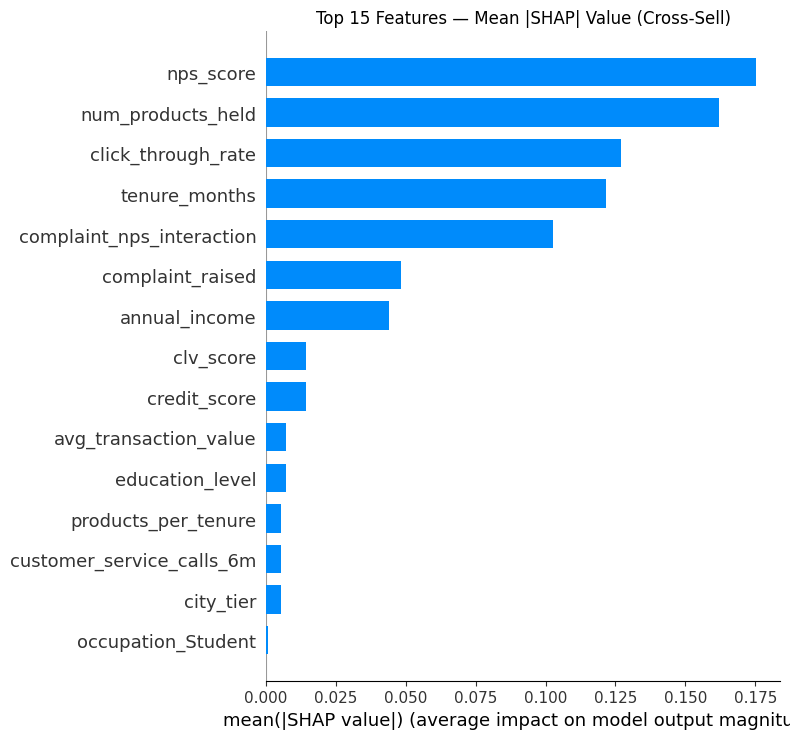

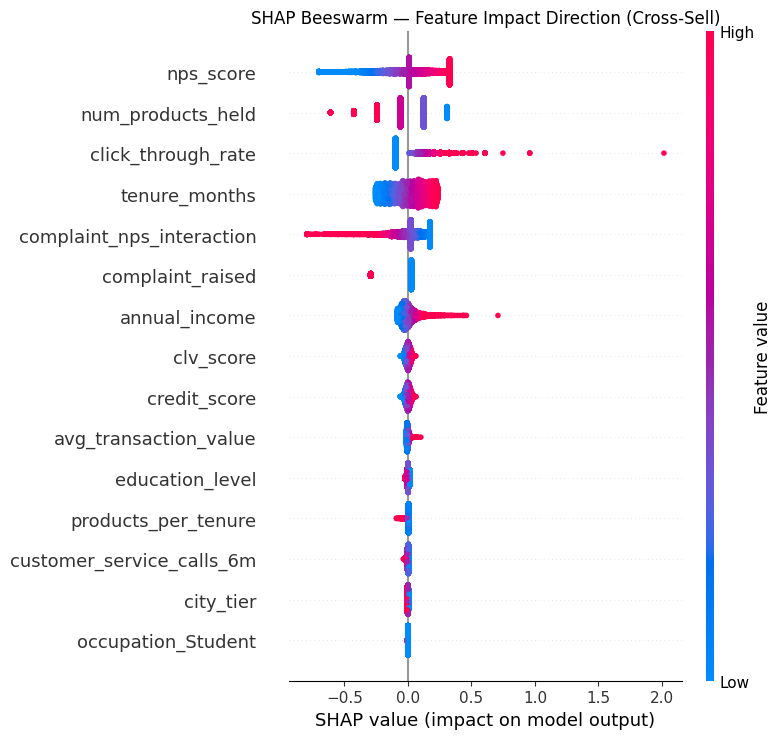


Waterfall plot for sample customer (Cross-Sell):


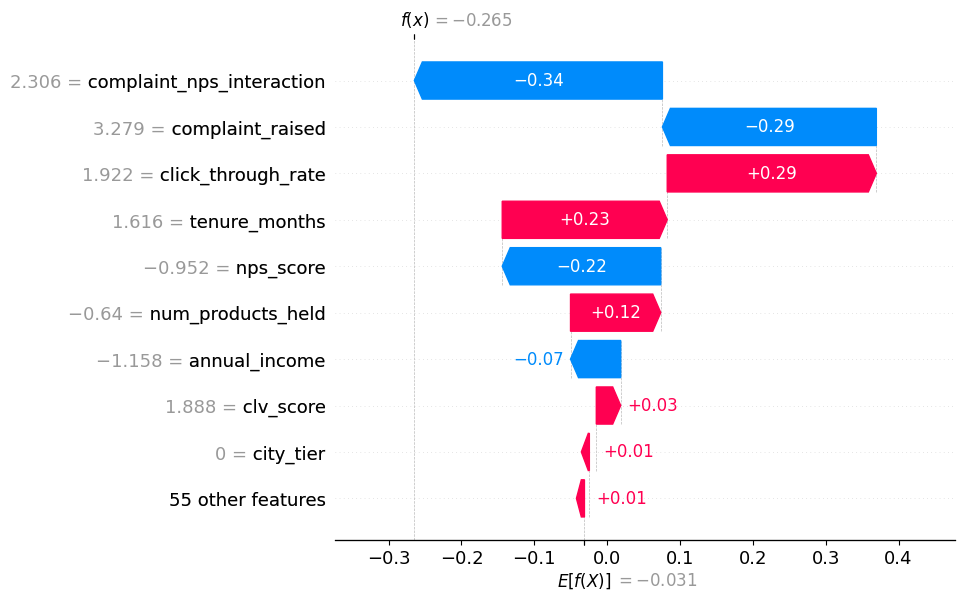

In [35]:

print("  CROSS-SELL SHAP ANALYSIS")

inner_cs_lr = lr_cs_search.best_estimator_

ohe_feature_names_cs = (
    cs_preprocessor.named_transformers_['nom']['encode']
    .get_feature_names_out(nominal_cols)
    .tolist()
)
cs_feature_names = numeric_cols + list(ordinal_cols_map.keys()) + ohe_feature_names_cs

X_cs_val_df = pd.DataFrame(X_cs_val_prep, columns=cs_feature_names)

print(f'Cross-sell feature matrix shape: {X_cs_val_df.shape}')
print(f'Feature names count:  {len(cs_feature_names)}')

masker_cs = shap.maskers.Independent(X_cs_val_df, max_samples=len(X_cs_val_df))
explainer_cs = shap.LinearExplainer(inner_cs_lr, masker_cs)
shap_values_cs = explainer_cs.shap_values(X_cs_val_df)

print('SHAP values computed.')

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_cs, X_cs_val_df, plot_type='bar', max_display=15, show=False)
plt.title('Top 15 Features — Mean |SHAP| Value (Cross-Sell)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_cs, X_cs_val_df, max_display=15, show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction (Cross-Sell)')
plt.tight_layout()
plt.show()

print("\nWaterfall plot for sample customer (Cross-Sell):")
customer_idx = 0
shap.waterfall_plot(shap.Explanation(
    values=shap_values_cs[customer_idx],
    base_values=explainer_cs.expected_value,
    data=X_cs_val_df.iloc[customer_idx],
    feature_names=cs_feature_names
))

In [36]:

print("  CROSS-SELL PROFIT BY CONTACT CAPACITY")

print(f"\n{'Capacity':<10} {'Contacts':<12} {'Threshold':<12} {'Precision':<12} {'Recall':<10} {'Profit':<15}")

for capacity_pct in [5, 10, 15, 20, 25, 30, 40, 50, 75, 100]:
    max_contacts_cap = int(capacity_pct / 100 * len(y_cs_val))
    best_profit_cap = -np.inf
    best_thresh_cap = None
    best_precision = 0
    best_recall = 0
    best_contacts = 0
    
    for t in np.linspace(0.01, 0.99, 500):
        y_flag = (y_cs_prob_val >= t).astype(int)
        contacts = y_flag.sum()
        if contacts <= max_contacts_cap:
            tp = ((y_flag == 1) & (y_cs_val == 1)).sum()
            profit = tp * REVENUE_PER_ACCEPT - contacts * COST_PER_CONTACT
            if profit > best_profit_cap:
                best_profit_cap = profit
                best_thresh_cap = t
                best_precision = tp / contacts if contacts > 0 else 0
                best_recall = tp / y_cs_val.sum()
                best_contacts = contacts
    
    print(f"{capacity_pct:>3}%      {best_contacts:>8.1f}   {best_thresh_cap:>8.3f}   {best_precision*100:>6.1f}%       {best_recall*100:>6.1f}%   ${best_profit_cap:>12,.0f}")

print(f"   OPTIMAL CAPACITY: 30%")
print(f"     Profit on TEST: ${cs_profit_test:,.0f}")
print(f"     Contacts on TEST: {cs_contacts_test:.1f} ({cs_contacts_test/len(y_cs_test)*100:.1f}% of customers)")
print(f"     Recall on TEST: {cs_recall_test*100:.1f}%")
print(f"     Precision on TEST: {cs_precision_test*100:.1f}%")

  CROSS-SELL PROFIT BY CONTACT CAPACITY

Capacity   Contacts     Threshold    Precision    Recall     Profit         
  5%         366.0      0.456     47.3%          8.0%   $      32,770
 10%         741.0      0.418     45.6%         15.6%   $      63,895
 15%        1126.0      0.391     44.8%         23.3%   $      95,370
 20%        1494.0      0.371     44.1%         30.4%   $     124,330
 25%        1847.0      0.356     42.8%         36.4%   $     148,765
 30%        2222.0      0.340     41.5%         42.5%   $     173,290
 40%        2965.0      0.312     39.5%         54.0%   $     219,375
 50%        3764.0      0.287     37.2%         64.5%   $     261,180
 75%        5609.0      0.224     33.0%         85.4%   $     342,555
100%        7483.0      0.071     29.0%        100.0%   $     396,185
   OPTIMAL CAPACITY: 30%
     Profit on TEST: $165,995
     Contacts on TEST: 2201.0 (29.2% of customers)
     Recall on TEST: 40.8%
     Precision on TEST: 40.2%


In [37]:
from networkx.algorithms import summarization

df_score = df.drop(columns=DROP_COLS + ['cross_sell_accepted', 'churned']).copy()
df_score = engineer_features(df_score)

X_all_prep = preprocessor.transform(df_score)

report = df[['customer_id', 'churned', 'cross_sell_accepted', 'clv_segment']].copy()
report['churn_prob'] = final_model.predict_proba(X_all_prep)[:, 1]

p33 = report['churn_prob'].quantile(0.33)
p66 = report['churn_prob'].quantile(0.66)

print(f"Score distribution:")
print(f"  Min:    {report['churn_prob'].min():.4f}")
print(f"  P33:    {p33:.4f}  Low/Medium boundary")
print(f"  Median: {report['churn_prob'].median():.4f}")
print(f"  P66:    {p66:.4f}  Medium/High boundary")
print(f"  Max:    {report['churn_prob'].max():.4f}")
print(f"  Mean:   {report['churn_prob'].mean():.4f}  (true base rate: {df['churned'].mean():.4f})")

labels = ['Low Risk', 'Medium Risk', 'High Risk']
report['churn_risk_band'] = pd.cut(
    report['churn_prob'],
    bins=[0, p33, p66, 1.0],
    labels=labels,
    include_lowest=True
)

summary = report.groupby('churn_risk_band', observed=True).agg(
    customers        =('customer_id',  'count'),
    actual_churn_rate=('churned',       'mean'),
    avg_churn_prob   =('churn_prob',    'mean'),
    min_prob         =('churn_prob',    'min'),
    max_prob         =('churn_prob',    'max'),
).round(4)
print("\nCustomer Risk Band Summary (percentile-based):")
print(summary)

Score distribution:
  Min:    0.0172
  P33:    0.0943  Low/Medium boundary
  Median: 0.1218
  P66:    0.1570  Medium/High boundary
  Max:    0.8827
  Mean:   0.1631  (true base rate: 0.1627)

Customer Risk Band Summary (percentile-based):
                 customers  actual_churn_rate  avg_churn_prob  min_prob  \
churn_risk_band                                                           
Low Risk             19800             0.0641          0.0682    0.0172   
Medium Risk          19800             0.1246          0.1224    0.0943   
High Risk            20400             0.2953          0.2946    0.1570   

                 max_prob  
churn_risk_band            
Low Risk           0.0943  
Medium Risk        0.1570  
High Risk          0.8827  


In [38]:
retention_targets = (
    report[report['churned'] == 0]
    .sort_values('churn_prob', ascending=False)
    .head(1000)
    [['customer_id', 'churn_prob', 'churn_risk_band', 'clv_segment']]
    .reset_index(drop=True)
)
print(f"Top 10 retention targets:")
print(retention_targets.head(10).to_string())

df_cs_score = df[df['churned'] == 0].drop(columns=CS_DROP + ['cross_sell_accepted']).copy()
df_cs_score = engineer_features(df_cs_score)

X_cs_all_prep = cs_preprocessor.transform(df_cs_score)

cs_report = df[df['churned'] == 0][['customer_id', 'cross_sell_accepted', 'clv_segment']].copy()
cs_report['accept_prob'] = cs_model.predict_proba(X_cs_all_prep)[:, 1]

cross_sell_targets = (
    cs_report
    .sort_values('accept_prob', ascending=False)
    .head(1000)
    [['customer_id', 'accept_prob', 'clv_segment']]
    .reset_index(drop=True)
)
print("\nTop 10 cross-sell targets:")
print(cross_sell_targets.head(10).to_string())

Top 10 retention targets:
  customer_id  churn_prob churn_risk_band clv_segment
0  CUST031421    0.869508       High Risk         Low
1  CUST028888    0.844501       High Risk         Low
2  CUST050293    0.842605       High Risk         Low
3  CUST050096    0.834818       High Risk         Low
4  CUST033859    0.825909       High Risk         Low
5  CUST008832    0.812340       High Risk         Low
6  CUST027160    0.800567       High Risk        High
7  CUST023988    0.792520       High Risk         Low
8  CUST041644    0.792212       High Risk         Low
9  CUST044980    0.792108       High Risk      Medium

Top 10 cross-sell targets:
  customer_id  accept_prob clv_segment
0  CUST021085     0.830634     Premium
1  CUST044983     0.823244     Premium
2  CUST005095     0.761792     Premium
3  CUST031766     0.708063     Premium
4  CUST033471     0.704551     Premium
5  CUST052034     0.672913     Premium
6  CUST022290     0.672008     Premium
7  CUST019273     0.664476     Premium
8

In [39]:
os.makedirs('models', exist_ok=True)

joblib.dump(preprocessor,    'models/churn_preprocessor.pkl')
joblib.dump(final_model,     'models/churn_model.pkl')
joblib.dump(cs_preprocessor, 'models/cs_preprocessor.pkl')
joblib.dump(cs_model,        'models/cs_model.pkl')

config = {
    'churn_threshold':     float(selected_threshold),
    'crosssell_threshold': float(best_cs_thresh),
}
with open('models/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("All models saved.")

retention_targets.to_csv('retention_targets.csv', index=False)
print(f"Saved retention_targets.csv — {len(retention_targets)} customers")

cross_sell_targets.to_csv('cross_sell_targets.csv', index=False)
print(f"Saved cross_sell_targets.csv — {len(cross_sell_targets)} customers")

All models saved.
Saved retention_targets.csv — 1000 customers
Saved cross_sell_targets.csv — 1000 customers
